# Módulo 4: Construcción de características

## Tratamiento de categóricos II: WoE

#### Objetivo 

* Comprender cómo es que los modelos de ML pueden consumir categorías y como éstas pasan a ser números.
* Aprender sobre los dos métodos más utilizados en ML y sustitución de categóricas: _Weight of evidence_.

#### Actividad 1
Tomar el dataset `actividad_10,0a` y conforme a los tipos de encoders realizar:
* WoE:
    * Generar un modelo con todas las variables (incluyendo las categóricas) y otro solo con las numéricas (originales) y comparar el performance.


#### Actividad 2
Tomar la base de datos `Automobile_data.csv` de la plataforma y:
* Generar un análisis exploratorio básico.
    * Identifica variables categóricas y numéricas.
    * Identifica si hay valores faltantes.
    * Convierte la variable de respuesta (`price`) a numérica. 
* 
* Escoge uno de los dos métodos en clase y encodea tus variables categóricas. 
* Después de generar sets de entrenamiento y de prueba (considera la normalización de los datos en caso de ser necesario) genera un modelo de regresión (`LinearRegression`) con todas tus variables y otro solo con las variables numéricas originales. 
* Mide en los sets de prueba de ambos modelos el performance. 
* Responde:
    * ¿Cuál de los dos métodos (con categóricas / sin categóricas) tuvo mejor performance? ¿Por qué?
    * ¿Qué ventaja tiene usar métodos para encodear variables categóricas? 
    * ¿Qué metodo de encoding utilizarías en un dataset con categorías con alta granularidad? 
    * ¿Qué posible desventaja podría ocurrir en caso de usar un modelo en producción con alguno de los métodos de encodeo vistos en clase?
    
    


In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import make_classification
from matplotlib import pyplot as plt
import os

plt.style.use('ggplot')
%matplotlib inline
seed = 28
path = '.'

Ya hemos aprendido sobre el uso de variables categóricas en modelos de ML. El día de hoy platicaremos sobre dos de los métodos más útiles en cuanto a tratamiento de categóricos: 

* Weight of evidence.

Ambos métodos están relacionados y en pocas palabras, utilizan la distribución de la variable de respuesta a la hora de definir categorías. 

Hay que tener mucho cuidado con el uso de estos métodos pues **potencialmente pueden generar target leakage**. 

## Weight of evidence

In [7]:
df = pd.read_csv('actividad_10,0a.csv')

In [8]:
df.head()

,Edad,Estado,Tipo_sangre,Salario
0,31.478456,Jalisco,B,0
1,31.858215,Sinaloa,B,0
2,52.755947,Jalisco,A,0
3,45.676041,Jalisco,A,0
4,37.337388,Jalisco,A,1


El procedimiento de los WoEs radica en la identificación de eventos positivos y negativos de una variable (independientemente del significado del uno y del cero) y usar esa proporción para definir el valor del WoE en la categoría. 


$$
WoE = \ln \frac{\text{% 1s}}{\text{% 0s}}
$$

Para definir el concepto del porcentaje, simplemente calculamos la proproción de cada grupo en la categoría: 

$$
\text{% 1s} = \frac{\text{1s parciales}}{\text{1s totales}}
$$


Con el caso de negativos se haría algo similar. 

#### Estado

Primero obtenemos los 1s y los counts de las categorías individuales. 

In [9]:
primer_paso = df.groupby('Estado').agg({'Salario':['sum', 'count']})

In [10]:
primer_paso

Salario      
            sum count
Estado               
CDMX          6     7
Jalisco      26    54
Sinaloa       5    14

Ahora obtenemos los malos como una diferencia de los dos anteriores.

In [12]:
# Removiendo columnas dobles
primer_paso = primer_paso['Salario']

In [13]:
primer_paso.loc[:, 'ceros'] = primer_paso['count'] - primer_paso['sum']

C:\Users\TAJ\AppData\Local\Temp\ipykernel_18288\2451507197.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primer_paso.loc[:, 'ceros'] = primer_paso['count'] - primer_paso['sum']


In [14]:
props_ls = primer_paso['sum'] / primer_paso['sum'].sum()
props_ls

Estado
CDMX       0.162162
Jalisco    0.702703
Sinaloa    0.135135
Name: sum, dtype: float64

Ahora calculamos las proporciones. 

In [15]:
props_0s = primer_paso['ceros'] / primer_paso['ceros'].sum()
props_0s

Estado
CDMX       0.026316
Jalisco    0.736842
Sinaloa    0.236842
Name: ceros, dtype: float64

Antes de calcular las proporciones finales, vamos a definir un $\epsilon$ para evitar las visiones entre cero. 

Este valor es variable, no tiene que ser siempre 1 pues esta sustitución es meramente con fines académicos.



Ahora calculamos las proporciones finales

In [16]:
props_finales = props_ls / props_0s
props_finales

Estado
CDMX       6.162162
Jalisco    0.953668
Sinaloa    0.570571
dtype: float64

In [17]:
woe = np.log(props_finales)
woe

Estado
CDMX       1.818428
Jalisco   -0.047440
Sinaloa   -0.561118
dtype: float64

In [18]:
df.groupby('Estado')['Salario'].value_counts()

Estado   Salario
CDMX     1           6
         0           1
Jalisco  0          28
         1          26
Sinaloa  0           9
         1           5
Name: count, dtype: int64

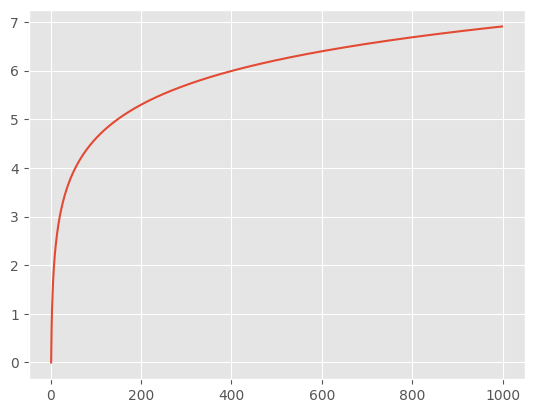

In [19]:
x = range(1, 1000)
y = np.log(x)
plt.plot(x, y)
plt.show()

Recordemos: ¿Cómo funciona el logaritmo neperiano? 

La interpretación de los `WoEs` es la siguiente: 

* El signo ya nos dice algo: El sentido.
* La magnitud del dato nos dice qué tanto se inclina hacia es sentido. 

Con mayor detalle: 
* Valores positivos de mayor magnitud tienden a tener mayor concentración de gente _buena_ (con la categoría de "1"). 
* Contrario al punto anterior, entre mayor magnitud en sentido negativo tenga el `WoE`, mayor concentración de gente con categoría de cero. 


#### Ventajas
* Signo y magnitud están directamente relacionados con el problema.
* Es rápido de calcular. 
* Es directamente interpretable. 
* No generar columnas extras. 


#### Desventajas
* Hay un ligero leak al incluir la respuesta de manera directa. 
* Se debe de tener mucho cuidado al calcularse con datos únicamente de entrenamiento.
* Se deben de cuidar categorías "pequeñas" pues al existir una división, puede haber problemas por cantidades pequeñas.
* Debe de tenerse cuidado con categorías que no tengan "ceros", pues pueden llegar a existir divisiones entre cero. 

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:

predictores = [c for c in df if c != 'Salario'] 

In [24]:
train_x, test_x, train_y, test_y = train_test_split(
    df[predictores],
    df['Salario'],
    test_size = 2,
    random_state=seed
)

In [26]:
# Sacando numéricos
numeric_cols = df[predictores].select_dtypes(exclude=['object']).columns
numeric_cols

Index(['Edad'], dtype='object')

In [27]:
# Sacando la variable de respuesta
mean = train_x[numeric_cols].mean()
stds = train_x[numeric_cols].std()

In [28]:
# Obteniendo medias y desviaciones estándar

train_x[numeric_cols] = (train_x[numeric_cols] - mean) / stds

In [29]:
# Normalizando set de entrenamiento
test_x[numeric_cols] = (test_x[numeric_cols] - mean) / stds

In [13]:
# Normalizando set de prueba


In [30]:
# SAcando variables categóricas
categorical_cols = df[predictores].select_dtypes(['object']).columns
categorical_cols

Index(['Estado', 'Tipo_sangre'], dtype='object')

Obtendremos los WoEs con el set de entrenamiento y después solo sustituiremos en el set de prueba:

In [ ]:
woes = {}

for col in categorical_cols:

    counts = df.groupby(col).agg({'Salario': ['sum', 'count']})['Salario']

    counts['bads'] = counts['count'] - counts['sum']

    props_ls = counts['sum'] / counts['sum'].sum()
    props_0s = counts['bads'] / counts['bads'].sum()

    props_final = props_ls / 

In [15]:


    # Sacando counts

    
    # Sacando count de bads

    
    # SAcando proporciones
    
    # Proporción final

    
    # Obteniendo logaritmo

    
    # Guardando 


Reemplazaremos en entrenamientos y tests con el mismo diccionario:

Ahora sí, generaremos el modelo: 

Midiendo performance:

Hagamos un intento son variables categóricas: